# Visual-TCAV PyTorch Library Guide

This notebook replicates the experiment from `visual_tcav_demo.ipynb` (FlexibleTNet
circle detection on AIXI-Shape) but uses the **`VisualTCAV_pytorch`** library API
instead of standalone functions.

**Comparison:**
- `visual_tcav_demo.ipynb`: loose functions + Captum directly, good for understanding the math
- This notebook: uses `Model`, `LocalVisualTCAV`, `GlobalVisualTCAV` classes from the library

---

## 1. Setup

In [1]:
import sys, os, csv
import numpy as np
from pathlib import Path
from itertools import combinations

import torch
import torch.nn.functional as F
from PIL import Image
from torchvision import transforms

# Project paths
# Adjust PROJECT_ROOT to point to your TCAV project that contains
# the FlexibleTNet model definition, weights, and AIXI-Shape data.
PROJECT_ROOT = Path(os.path.abspath('')).parent.parent
sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

from model.model_dylan import FlexibleTNet

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Project root: {PROJECT_ROOT}')
print(f'Device: {DEVICE}')

METHOD_CAV = "classifier"
CONCEPTS = ['circle_full', 'cross_full', 'square_full', 'circle_half_top', 'square_corner_bl', 'cross_arm_right']
LAYERS = []

Project root: /home/dylan-canning/Documents/Testing-with-Concept-Activation-Vectors/Testing-with-Concept-Activation-Vectors
Device: cpu


## 2. Load FlexibleTNet model

In [2]:
WEIGHTS_PATH = PROJECT_ROOT / 'weights' / 'flex_circle_only.pt'

nn_model = FlexibleTNet(
    num_channels=1, num_classes=1,
    conv_channels=[8], fc_layers=[32],
    dropout_p=0.2, do_sigmoid=True, size_img=128,
)
nn_model.load_state_dict(torch.load(WEIGHTS_PATH, map_location=DEVICE, weights_only=True))
nn_model.to(DEVICE).eval()

print(f'Model loaded from {WEIGHTS_PATH}')
print(nn_model)

Model loaded from /home/dylan-canning/Documents/Testing-with-Concept-Activation-Vectors/Testing-with-Concept-Activation-Vectors/weights/flex_circle_only.pt
FlexibleTNet(
  (conv_layers): Sequential(
    (0): Sequential(
      (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=same)
      (1): ReLU()
      (2): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
  )
  (fc_layers): Sequential(
    (0): Sequential(
      (0): Linear(in_features=32768, out_features=32, bias=True)
      (1): Dropout(p=0.2, inplace=False)
      (2): ReLU()
    )
  )
  (output): Linear(in_features=32, out_features=1, bias=True)
  (final_act): Sigmoid()
)


## 3. Wrap with VisualTCAV_pytorch.Model

The library's `Model` class wraps an `nn.Module` with metadata (labels,
preprocessing, image shape). Key points for FlexibleTNet:

- **`graph_path_filename`**: Pass the `nn.Module` directly (no file path needed)
- **`label_path_filename`**: Pass labels as a list (binary: circle present/absent)
- **`image_shape=[128, 128, 1]`**: Override the default 224x224x3 since this is grayscale 128x128
- **`binary_classification=True`**: Enables the binary attribution split (pos/neg class)
- **`preprocessing_function`**: Converts numpy [N, H, W, 1] to normalized floats

In [3]:
from VisualTCAV_pytorch import Model, LocalVisualTCAV, GlobalVisualTCAV

# Preprocessing: normalize grayscale images to [0, 1]
# The library loads images as numpy [N, H, W, C] and this function is applied
# before feeding to the model. For FlexibleTNet: divide by 255.
def preprocess_grayscale(imgs):
    return imgs.astype(np.float32) / 255.0

vtcav_model = Model(
    model_name='FlexibleTNet_circle',
    graph_path_filename=nn_model,           # Pass nn.Module directly
    label_path_filename=['Circle present', 'Circle absent'],  # Binary labels
    preprocessing_function=preprocess_grayscale,
    binary_classification=True,
    max_examples=500,
    image_shape=[128, 128, 1],              # Grayscale 128x128
)


print(f'Model: {vtcav_model.model_name}')
print(f'Image shape: {vtcav_model.image_shape}')
print(f'Binary: {vtcav_model.binary_classification}')

/home/dylan-canning/Documents/Testing-with-Concept-Activation-Vectors/Testing-with-Concept-Activation-Vectors/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Model: FlexibleTNet_circle
Image shape: [128, 128, 1]
Binary: True


## 4. Directory Structure

The library expects this directory layout:
```
concept_images_dir/
  circle_full/       # concept images
  cross_full/
  square_full/
  random_pool_4/     # random/negative images
test_images_dir/
  <test_image>.png   # for local explanations
  <folder>/          # for global explanations (all images in a folder)
```

We point the library at the AIXI-Shape data directories.

In [4]:
CONCEPTS_DIR = str(PROJECT_ROOT / 'data' / 'concepts')
TEST_IMAGES_DIR = str(PROJECT_ROOT / 'data' / 'aixi_shape' / 'val')

print(f'Concepts dir: {CONCEPTS_DIR}')
print(f'Test images dir: {TEST_IMAGES_DIR}')
print(f'Concept folders: {sorted(os.listdir(CONCEPTS_DIR))}')

Concepts dir: /home/dylan-canning/Documents/Testing-with-Concept-Activation-Vectors/Testing-with-Concept-Activation-Vectors/data/concepts
Test images dir: /home/dylan-canning/Documents/Testing-with-Concept-Activation-Vectors/Testing-with-Concept-Activation-Vectors/data/aixi_shape/val
Concept folders: ['.DS_Store', 'braided', 'chequered', 'circle_full', 'circle_half_bottom', 'circle_half_left', 'circle_half_right', 'circle_half_top', 'circle_quarter_bl', 'circle_quarter_br', 'circle_quarter_tl', 'circle_quarter_tr', 'cross_arm_bottom', 'cross_arm_horizontal', 'cross_arm_left', 'cross_arm_right', 'cross_arm_top', 'cross_arm_vertical', 'cross_full', 'dotted', 'frekeled', 'random_0', 'random_1', 'random_2', 'random_3', 'random_pool', 'random_pool_2', 'random_pool_3', 'random_pool_4', 'spiralled', 'square_corner_bl', 'square_corner_br', 'square_corner_tl', 'square_corner_tr', 'square_edge_bottom', 'square_edge_left', 'square_edge_right', 'square_edge_top', 'square_full', 'square_half_bottom

## 5. Pick test images (same as demo)

Find one image with circles and one without from the validation set.

Loaded metadata for indices: 52 and 105


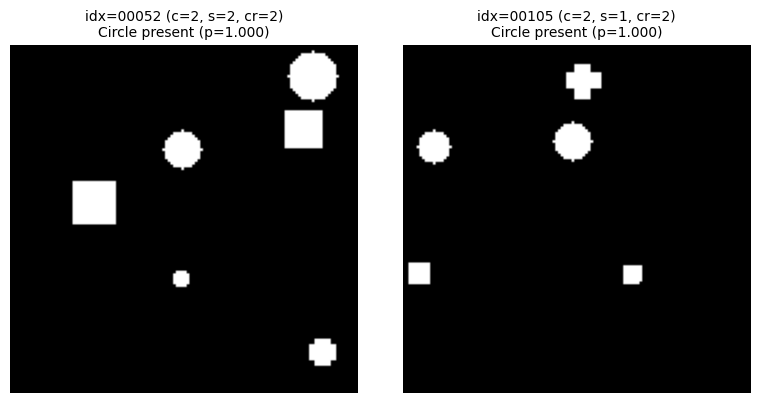

Image 1: 00052.png
Image 2: 00105.png


In [5]:
import matplotlib.pyplot as plt

TARGET_IDX_WITH = 52   # Replace with the index you want for the "with circles" slot
TARGET_IDX_WITHOUT = 105 # Replace with the index you want for the "without circles" slot

val_csv = PROJECT_ROOT / 'data' / 'aixi_shape' / 'val' / 'dades.csv'
val_dir = PROJECT_ROOT / 'data' / 'aixi_shape' / 'val'

with open(val_csv) as f:
    rows = list(csv.DictReader(f, delimiter=';'))

# Helper function to find a specific index's metadata in the CSV
def get_metadata_for_idx(target_idx, csv_rows):
    for r in csv_rows:
        if int(r['']) == target_idx:
            return (target_idx, int(r['c']), int(r['s']), int(r['cr']))
    raise ValueError(f"Index {target_idx} not found in CSV.")

# Fetch the metadata for your chosen indices
img_with = get_metadata_for_idx(TARGET_IDX_WITH, rows)
img_without = get_metadata_for_idx(TARGET_IDX_WITHOUT, rows)

print(f"Loaded metadata for indices: {img_with[0]} and {img_without[0]}")

# Setup Transforms
img_transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for ax, (idx, c, s, cr) in zip(axes, [img_with, img_without]):
    # Note: Fixed the hardcoded '52' here so it uses the 'idx' variable
    img = Image.open(val_dir / f'{idx:05d}.png')
    
    t = img_transform(img.convert('L')).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        p = nn_model(t).item()
        
    ax.imshow(np.array(img), cmap='gray')
    label = 'Circle present' if p > 0.5 else 'Circle absent'
    ax.set_title(f'idx={idx:05d} (c={c}, s={s}, cr={cr})\n{label} (p={p:.3f})', fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

print(f'Image 1: {img_with[0]:05d}.png')
print(f'Image 2: {img_without[0]:05d}.png')

## 6. Local Explanation (image with circles)

Uses `LocalVisualTCAV` to explain a single test image. The library handles:
1. Loading and preprocessing the test image
2. Computing CAVs (centroid-based by default)
3. Computing integrated gradients via Captum
4. Generating concept maps and attribution scores

In [8]:
# Create a local explainer for the image with circles
local_explainer = LocalVisualTCAV(
    test_image_filename=f'{img_with[0]:05d}.png',
    m_steps=50,
    model=vtcav_model,
    concept_images_dir=CONCEPTS_DIR,
    test_images_dir=TEST_IMAGES_DIR,
    random_images_folder='random_pool_4',
    cav_method=METHOD_CAV,     # Original Visual-TCAV approach
    device=DEVICE,
)

# Set concepts and layers
local_explainer.setConcepts(CONCEPTS)
local_explainer.setLayers(['conv_layers.0', 'fc_layers.0.0'])

# Run prediction first (required before explain)
predictions = local_explainer.predict(no_sort=True)
predictions.info()

# Show available layers
print(f'\nAvailable layers: {vtcav_model.getLayerNames()}')

+-----------------------------------------+
|        Model: FlexibleTNet_circle       |
+-----------+----------------+------------+
|   Image   |   Class name   | Confidence |
+-----------+----------------+------------+
| 00052.png | Circle present |     1      |
+-----------+----------------+------------+

Available layers: ['conv_layers', 'conv_layers.0', 'conv_layers.0.0', 'fc_layers', 'fc_layers.0', 'fc_layers.0.0', 'output']


In [9]:
# Run the explanation
local_explainer.explain(cache_cav=False, cache_random=False)

# Print attribution results
for concept_name in local_explainer.concepts:
    for layer_name in local_explainer.layers:
        cl = local_explainer.computations[layer_name][concept_name]
        attribs = {k: v.item() if isinstance(v, torch.Tensor) else v
                   for k, v in cl.attributions.items()}
        print(f'{concept_name} @ {layer_name}: {attribs}')

Layers:  50%|█████     | 1/2 [00:02<00:02,  2.90s/it]


IndexError: Dimension out of range (expected to be in range of [-2, 1], but got 2)

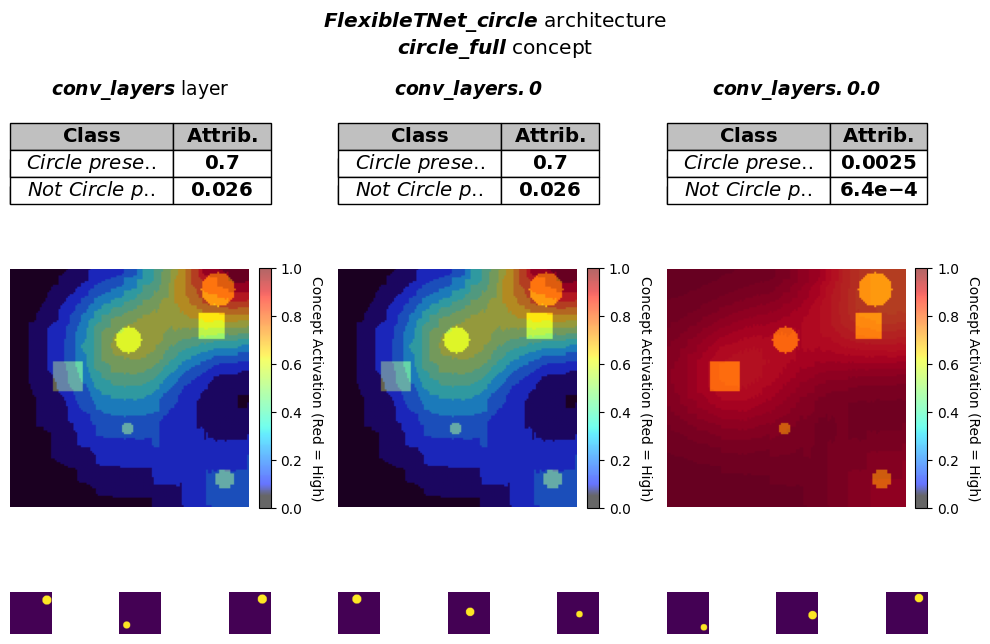

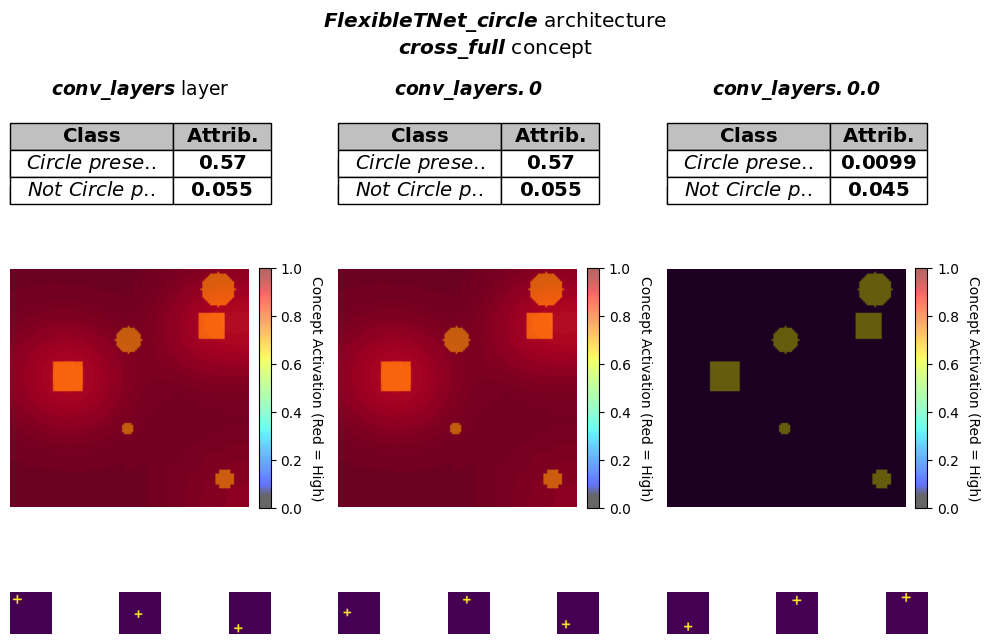

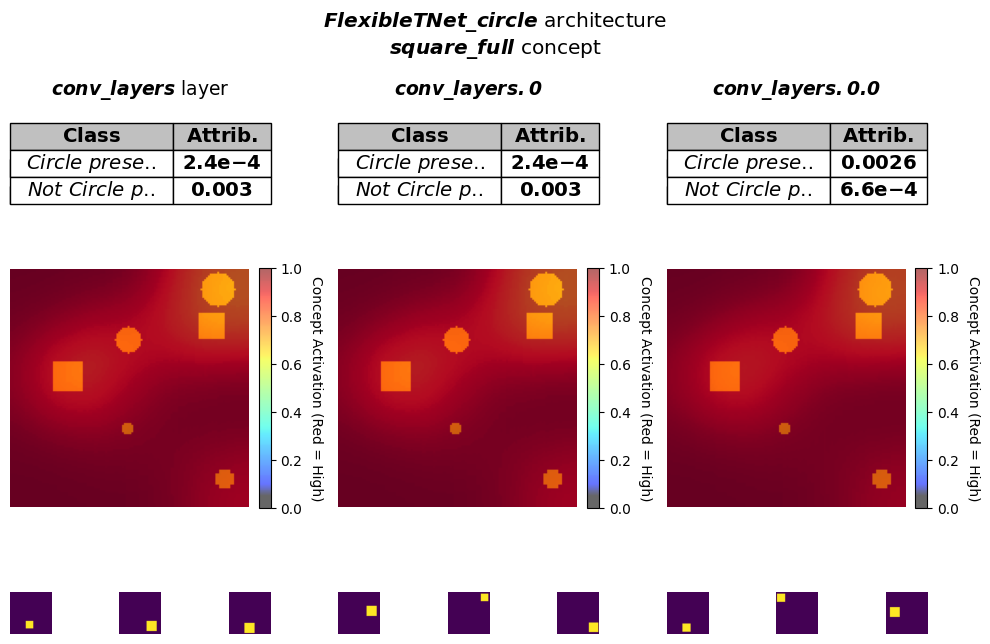

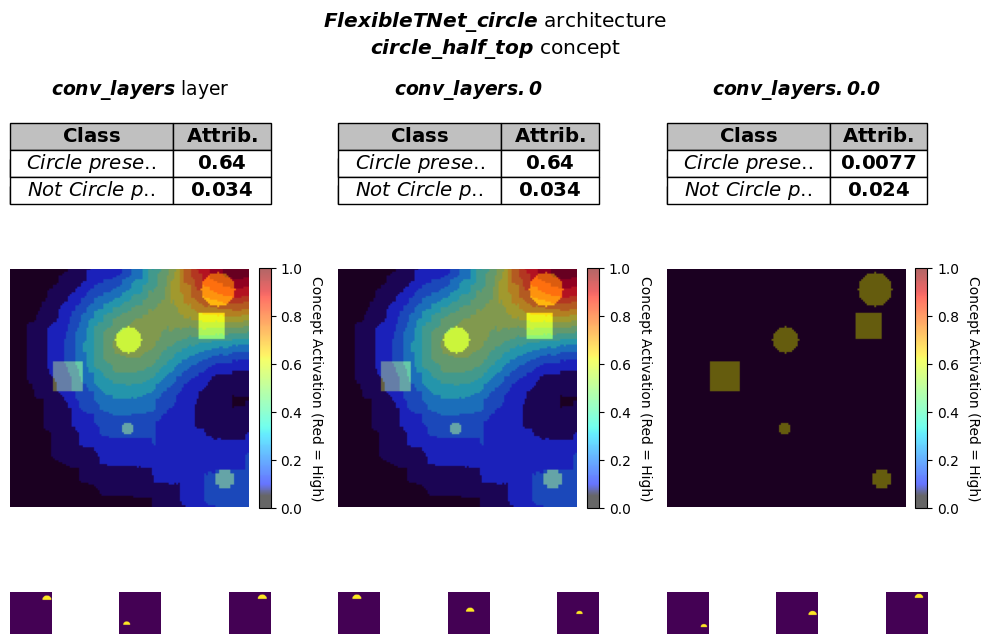

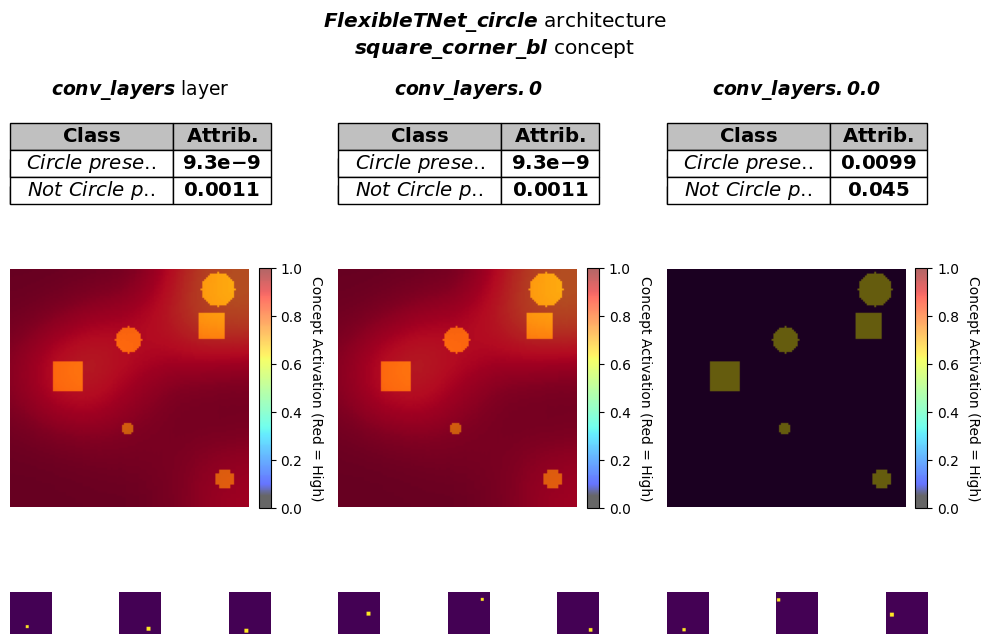

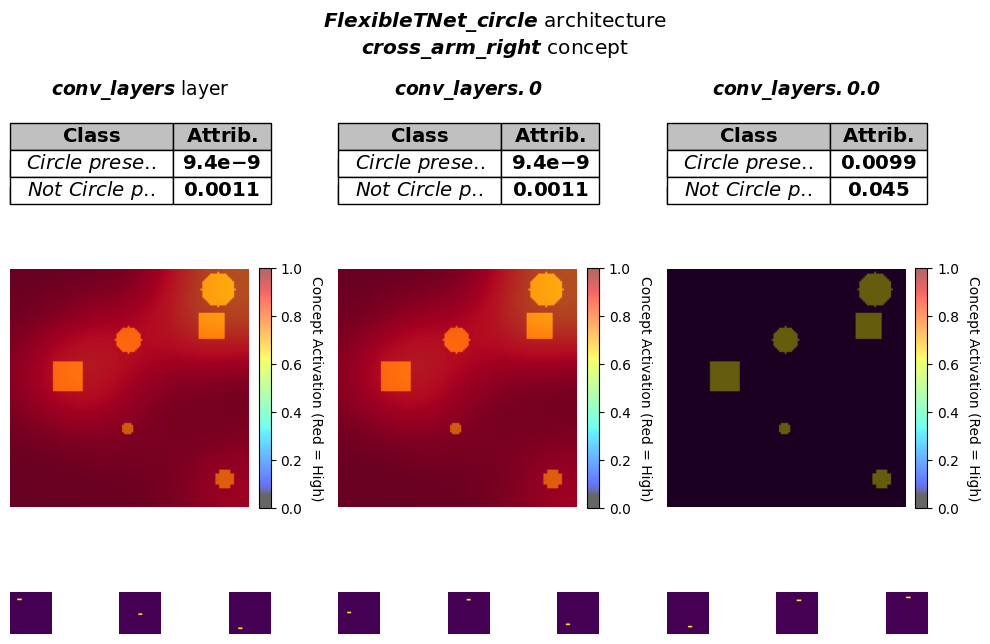

In [ ]:
# Plot heatmaps
local_explainer.plot()

## 7. Inspect CAVs

Compare the CAV directions and cosine similarities, same as in the demo notebook.

circle_full: norm=4.2112, emblem=(114.3196, 0.0000)
cross_full: norm=4.8513, emblem=(0.7202, 0.0957)
square_full: norm=5.4444, emblem=(0.4887, 0.3394)
circle_half_top: norm=4.7709, emblem=(71.9408, 0.0000)
square_corner_bl: norm=4.6701, emblem=(0.4541, 0.1848)
cross_arm_right: norm=4.6176, emblem=(0.4500, 0.1776)

Cosine similarities between CAV directions:
  circle_full vs cross_full: 0.6848
  circle_full vs square_full: 0.5149
  circle_full vs circle_half_top: 0.9074
  circle_full vs square_corner_bl: 0.5467
  circle_full vs cross_arm_right: 0.5480
  cross_full vs square_full: 0.9459
  cross_full vs circle_half_top: 0.9187
  cross_full vs square_corner_bl: 0.9808
  cross_full vs cross_arm_right: 0.9813
  square_full vs circle_half_top: 0.7982
  square_full vs square_corner_bl: 0.9745
  square_full vs cross_arm_right: 0.9724
  circle_half_top vs square_corner_bl: 0.8291
  circle_half_top vs cross_arm_right: 0.8299
  square_corner_bl vs cross_arm_right: 1.0000


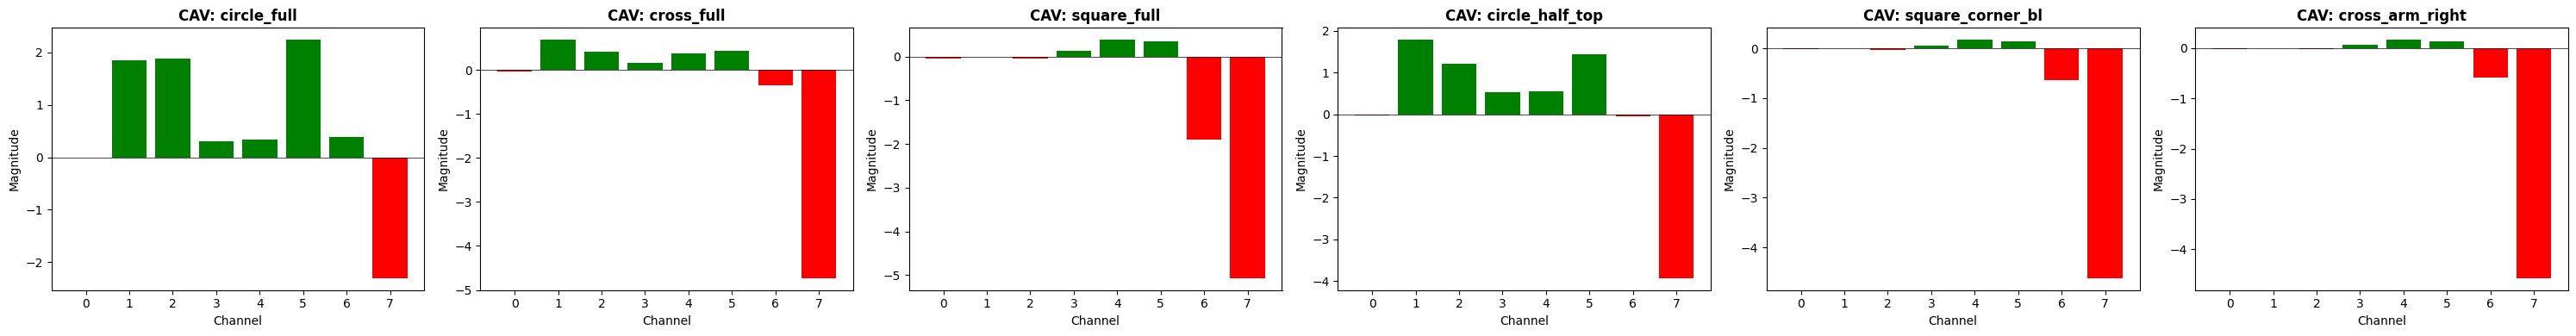

In [ ]:
concept_names = local_explainer.concepts
layer_name = local_explainer.layers[0]

# Extract CAV directions
cavs = {}
for cn in concept_names:
    cav = local_explainer.getCAVs(layer_name, cn)
    cavs[cn] = cav.direction
    print(f'{cn}: norm={cav.direction.norm():.4f}, '
          f'emblem=({cav.concept_emblem[0]:.4f}, {cav.concept_emblem[1]:.4f})')

# Cosine similarities
print('\nCosine similarities between CAV directions:')
for a, b in combinations(concept_names, 2):
    cos = F.cosine_similarity(
        cavs[a].unsqueeze(0), cavs[b].unsqueeze(0)
    ).item()
    print(f'  {a} vs {b}: {cos:.4f}')

# Per-channel direction bars
fig, axes = plt.subplots(1, len(concept_names), figsize=(5 * len(concept_names), 4))
for ax, name in zip(axes, concept_names):
    d = cavs[name].cpu().numpy()
    ax.bar(range(len(d)), d, color=['green' if v > 0 else 'red' for v in d])
    ax.set_title(f'CAV: {name}', fontweight='bold')
    ax.set_xlabel('Channel')
    ax.set_ylabel('Magnitude')
    ax.axhline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

## 8. Local Explanation (image without circles)

+-----------------------------------------+
|        Model: FlexibleTNet_circle       |
+-----------+----------------+------------+
|   Image   |   Class name   | Confidence |
+-----------+----------------+------------+
| 00105.png | Circle present |     1      |
+-----------+----------------+------------+


Layers: 100%|██████████| 1/1 [00:02<00:00,  2.28s/it]


circle_full @ conv_layers.0: {0: 0.8165315389633179, 1: 0.015442637726664543}
cross_full @ conv_layers.0: {0: 0.00013541767839342356, 1: 0.00018020060088019818}
square_full @ conv_layers.0: {0: 5.5304622947005555e-05, 1: 5.440230233944021e-05}
circle_half_top @ conv_layers.0: {0: 0.034947097301483154, 1: 0.0006795380031690001}
square_corner_bl @ conv_layers.0: {0: 5.6908025726443157e-05, 1: 6.192841101437807e-05}
cross_arm_right @ conv_layers.0: {0: 5.688207602361217e-05, 1: 6.193093577167019e-05}


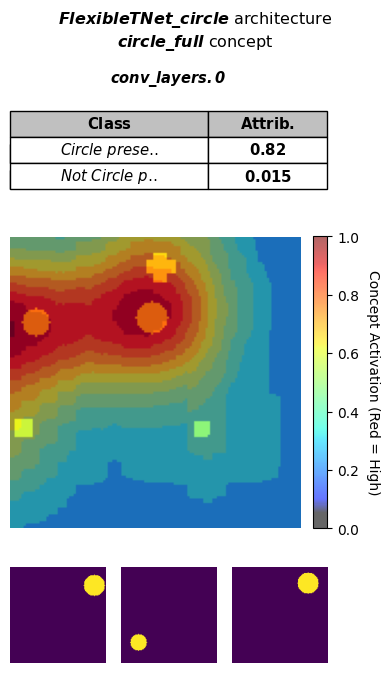

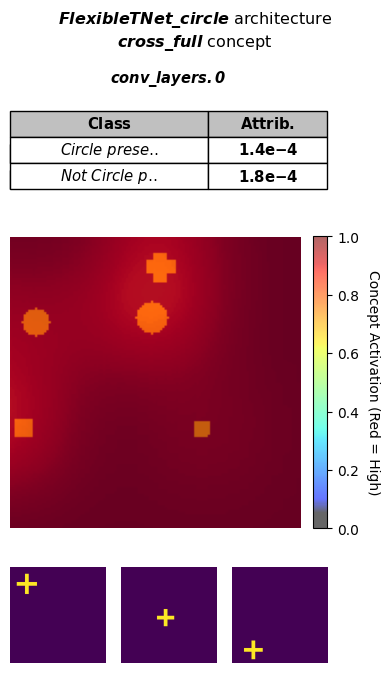

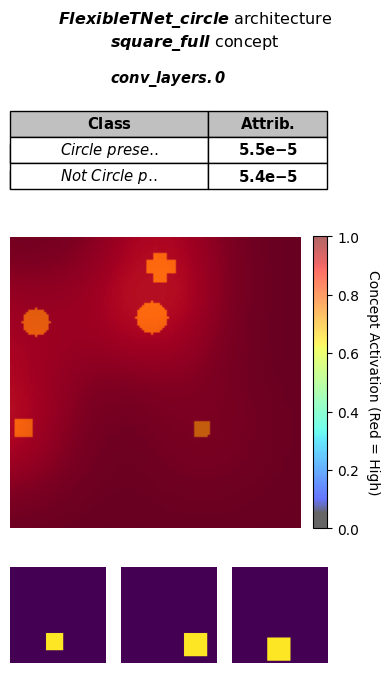

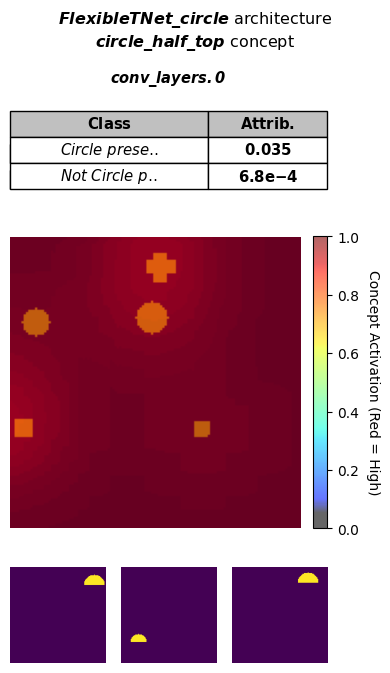

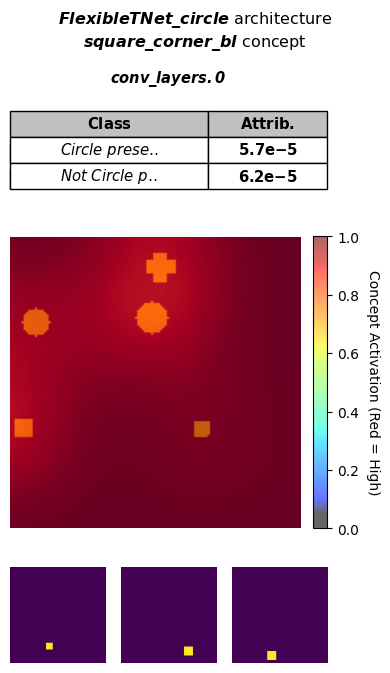

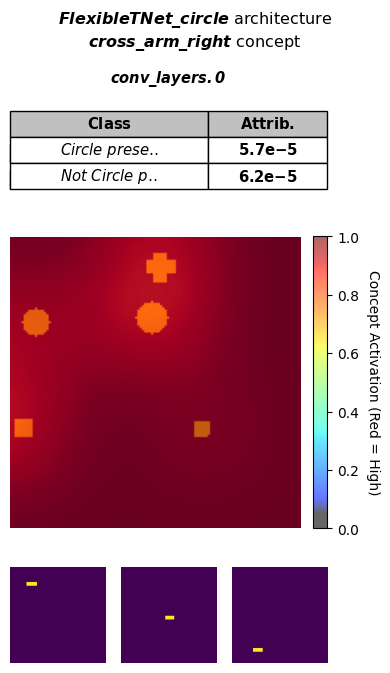

In [ ]:
local_explainer2 = LocalVisualTCAV(
    test_image_filename=f'{img_without[0]:05d}.png',
    m_steps=50,
    model=vtcav_model,
    concept_images_dir=CONCEPTS_DIR,
    test_images_dir=TEST_IMAGES_DIR,
    random_images_folder='random_pool_4',
    cav_method='centroid',
    device=DEVICE,
)

local_explainer2.setConcepts(CONCEPTS)
local_explainer2.setLayers(['conv_layers.0'])

predictions2 = local_explainer2.predict(no_sort=True)
predictions2.info()

local_explainer2.explain(cache_cav=False, cache_random=False)

for concept_name in local_explainer2.concepts:
    for layer_name in local_explainer2.layers:
        cl = local_explainer2.computations[layer_name][concept_name]
        attribs = {k: v.item() if isinstance(v, torch.Tensor) else v
                   for k, v in cl.attributions.items()}
        print(f'{concept_name} @ {layer_name}: {attribs}')

local_explainer2.plot()

## 9. Global Explanation

Uses `GlobalVisualTCAV` to aggregate attributions across multiple test images.

**Note:** The library's global explainer expects all test images in a single folder.
We first copy the selected images into separate group folders.

In [ ]:
import shutil

# Select 50 images per group (same as demo)
circle_indices, no_circle_indices = [], []
for r in rows:
    idx, c = int(r['']), int(r['c'])
    if c > 0 and len(circle_indices) < 50:
        circle_indices.append(idx)
    elif c == 0 and len(no_circle_indices) < 50:
        no_circle_indices.append(idx)

# Create temporary test image folders
global_test_dir = PROJECT_ROOT / 'data' / 'aixi_shape' / 'val_global_test'
for group_name, indices in [('circle_present', circle_indices), ('circle_absent', no_circle_indices)]:
    group_dir = global_test_dir / group_name
    group_dir.mkdir(parents=True, exist_ok=True)
    for idx in indices:
        src = val_dir / f'{idx:05d}.png'
        dst = group_dir / f'{idx:05d}.png'
        if not dst.exists():
            shutil.copy2(src, dst)

print(f'Circle present: {len(circle_indices)} images')
print(f'Circle absent:  {len(no_circle_indices)} images')
print(f'Test dir: {global_test_dir}')

Circle present: 50 images
Circle absent:  50 images
Test dir: /home/dylan-canning/Documents/Testing-with-Concept-Activation-Vectors/Testing-with-Concept-Activation-Vectors/data/aixi_shape/val_global_test


In [ ]:
# Global explanation: Circle Present group
global_circle = GlobalVisualTCAV(
    target_class='Circle present',
    test_images_folder='circle_present',
    m_steps=50,
    model=vtcav_model,
    concept_images_dir=CONCEPTS_DIR,
    test_images_dir=str(global_test_dir),
    random_images_folder='random_pool_4',
    cav_method=METHOD_CAV,
    device=DEVICE,
)

global_circle.setConcepts(CONCEPTS)
global_circle.setLayers(['conv_layers.0'])

print('Running global explanation - Circle Present...')
global_circle.explain(cache_cav=False, cache_random=False)

Running global explanation - Circle Present...


Layers: 100%|██████████| 1/1 [00:03<00:00,  3.99s/it]


In [ ]:
# Print stats
global_circle.statsInfo()

+------------------------------------------------------------------------------------+
|    Model: FlexibleTNet_circle; Class: Circle present; Examples: circle_present     |
+------------------+---------------+----------------------+--------------------------+
|     Concept      |     Layer     |     Attrib. mean     |    Attrib. 95.45% CI     |
+------------------+---------------+----------------------+--------------------------+
|   circle_full    | conv_layers.0 |   0.724 +- 0.0298    |    ['0.715', '0.732']    |
|    cross_full    | conv_layers.0 |   0.0913 +- 0.0684   |    ['0.072', '0.111']    |
|   square_full    | conv_layers.0 |  0.00148 +- 0.00102  |  ['0.00119', '0.00177']  |
| circle_half_top  | conv_layers.0 |   0.648 +- 0.0313    |    ['0.639', '0.656']    |
| square_corner_bl | conv_layers.0 | 0.00065 +- 0.000505  | ['0.000508', '0.000793'] |
| cross_arm_right  | conv_layers.0 | 0.000614 +- 0.000479 | ['0.000478', '0.000749'] |
+------------------+---------------+-------

In [ ]:
# Global explanation: Circle Absent group
global_no_circle = GlobalVisualTCAV(
    target_class='Circle present',   # Still targeting 'Circle present' class
    test_images_folder='circle_absent',
    m_steps=50,
    model=vtcav_model,
    concept_images_dir=CONCEPTS_DIR,
    test_images_dir=str(global_test_dir),
    random_images_folder='random_pool_4',
    cav_method=METHOD_CAV,
    device=DEVICE,
)

global_no_circle.setConcepts(CONCEPTS)
global_no_circle.setLayers(['conv_layers.0'])

print('Running global explanation - Circle Absent...')
global_no_circle.explain(cache_cav=False, cache_random=False)

Running global explanation - Circle Absent...


Layers: 100%|██████████| 1/1 [00:03<00:00,  3.90s/it]


In [ ]:
# Print stats
global_no_circle.statsInfo()

+---------------------------------------------------------------------------------+
|    Model: FlexibleTNet_circle; Class: Circle present; Examples: circle_absent   |
+------------------+---------------+--------------------+-------------------------+
|     Concept      |     Layer     |    Attrib. mean    |    Attrib. 95.45% CI    |
+------------------+---------------+--------------------+-------------------------+
|   circle_full    | conv_layers.0 |   0.313 +- 0.201   |    ['0.257', '0.37']    |
|    cross_full    | conv_layers.0 |  0.0124 +- 0.0179  |  ['0.00729', '0.0174']  |
|   square_full    | conv_layers.0 | 0.00404 +- 0.0069  |  ['0.00209', '0.00599'] |
| circle_half_top  | conv_layers.0 |   0.269 +- 0.175   |    ['0.219', '0.318']   |
| square_corner_bl | conv_layers.0 | 0.00192 +- 0.0034  | ['0.000962', '0.00288'] |
| cross_arm_right  | conv_layers.0 | 0.00183 +- 0.00324 | ['0.000916', '0.00275'] |
+------------------+---------------+--------------------+-------------------

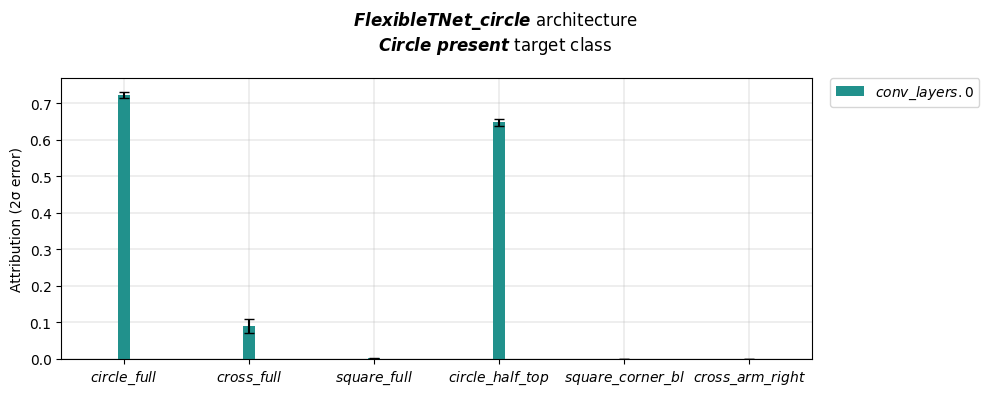

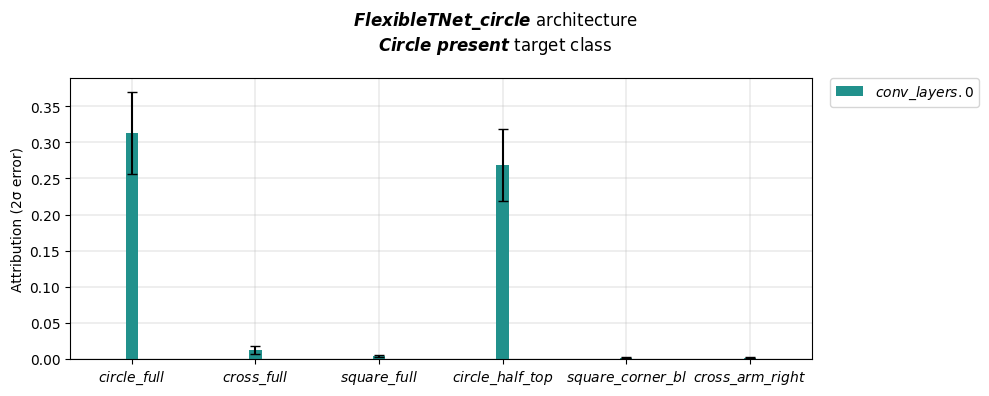

In [ ]:
# Plot both groups
global_circle.plot()
global_no_circle.plot()

## 10. Compare with classifier-based CAVs

The library supports switching from centroid-based CAVs (Visual-TCAV original)
to classifier-based CAVs (standard TCAV, Kim et al. 2018) via `cav_method='classifier'`.

This trains a linear SVM to separate concept vs random activations, using the
hyperplane normal as the CAV direction. It provides an accuracy metric but is
non-deterministic.

In [ ]:
# Local explanation with classifier-based CAVs for comparison
local_clf = LocalVisualTCAV(
    test_image_filename=f'{img_with[0]:05d}.png',
    m_steps=50,
    model=vtcav_model,
    concept_images_dir=CONCEPTS_DIR,
    test_images_dir=TEST_IMAGES_DIR,
    random_images_folder='random_pool_4',
    cav_method='classifier',    # <-- Switch to classifier-based CAVs
    device=DEVICE,
)

local_clf.setConcepts(CONCEPTS)
local_clf.setLayers(['conv_layers.0'])

predictions_clf = local_clf.predict(no_sort=True)
local_clf.explain(cache_cav=False, cache_random=False)

print('=== Classifier-based CAVs ===')
for concept_name in local_clf.concepts:
    cav = local_clf.getCAVs('conv_layers.0', concept_name)
    attribs = local_clf.computations['conv_layers.0'][concept_name].attributions
    attribs = {k: v.item() if isinstance(v, torch.Tensor) else v for k, v in attribs.items()}
    print(f'{concept_name}: accuracy={cav.accuracy:.3f}, attribs={attribs}')

print('\n=== Centroid-based CAVs (from section 6) ===')
for concept_name in local_explainer.concepts:
    attribs = local_explainer.computations['conv_layers.0'][concept_name].attributions
    attribs = {k: v.item() if isinstance(v, torch.Tensor) else v for k, v in attribs.items()}
    print(f'{concept_name}: attribs={attribs}')

Layers: 100%|██████████| 1/1 [00:02<00:00,  2.43s/it]

=== Classifier-based CAVs ===
circle_full: accuracy=1.000, attribs={0: 0.7006431221961975, 1: 0.025842653587460518}
cross_full: accuracy=0.990, attribs={0: 0.568411111831665, 1: 0.055251337587833405}
square_full: accuracy=0.975, attribs={0: 0.0002434964117128402, 1: 0.003016796661540866}
circle_half_top: accuracy=0.995, attribs={0: 0.6426210999488831, 1: 0.033908672630786896}
square_corner_bl: accuracy=0.995, attribs={0: 9.30192634029936e-09, 1: 0.0011323144426569343}
cross_arm_right: accuracy=0.995, attribs={0: 9.4281613627345e-09, 1: 0.0010802175384014845}

=== Centroid-based CAVs (from section 6) ===
circle_full: attribs={0: 0.7006431221961975, 1: 0.025842653587460518}
cross_full: attribs={0: 0.568411111831665, 1: 0.055251337587833405}
square_full: attribs={0: 0.0002434964117128402, 1: 0.003016796661540866}
circle_half_top: attribs={0: 0.6426210999488831, 1: 0.033908672630786896}
square_corner_bl: attribs={0: 9.30192634029936e-09, 1: 0.0011323144426569343}
cross_arm_right: attribs={

In [ ]:
# Compare CAV directions between centroid and classifier methods
print('Cosine similarity between centroid and classifier CAV directions:')
for cn in concept_names:
    d_centroid = local_explainer.getCAVs('conv_layers.0', cn).direction
    d_classifier = local_clf.getCAVs('conv_layers.0', cn).direction
    cos = F.cosine_similarity(
        d_centroid.unsqueeze(0), d_classifier.unsqueeze(0)
    ).item()
    print(f'  {cn}: {cos:.4f}')

Cosine similarity between centroid and classifier CAV directions:
  circle_full: 1.0000
  cross_full: 1.0000
  square_full: 1.0000
  circle_half_top: 1.0000
  square_corner_bl: 1.0000
  cross_arm_right: 1.0000


---

## Summary

This notebook demonstrated the full `VisualTCAV_pytorch` library API:

| Step | Class | What it does |
|------|-------|--------------|
| Model setup | `Model` | Wraps nn.Module with labels, preprocessing, image shape |
| Local explanation | `LocalVisualTCAV` | Single-image concept maps + per-class attributions |
| Global explanation | `GlobalVisualTCAV` | Aggregate attributions with statistics |
| CAV inspection | `getCAVs()` | Access directions, emblems, accuracy |

**CAV methods compared:**
- `cav_method='centroid'`: Visual-TCAV original (deterministic, fast)
- `cav_method='classifier'`: Standard TCAV (provides accuracy metric, requires sklearn)